# 04 — Exploratory Data Analysis & Visualizations

**Project:** F1 Track Personality 2020–2025
**Authors:** Matteo Asscher & Aksel Hatlem
**Input:** `data/processed/analysis_ready_<latest>.parquet` from Session 4 (2,618 rows × 28 columns)
**Output:**
- Six PNG figures in `reports/figures/` for the slide deck
- Three written findings (markdown cells at the end of the notebook)

## What this notebook produces

| # | Chart | Purpose |
|---|---|---|
| 1 | Season-average position over time (line) | Establish baseline: how each constructor's overall season performance evolved 2020–2025. |
| 2 | Distribution of `position_delta` (histogram) | Sanity check: shape and spread of our core metric. |
| 3 | DNF rate by constructor (bar) | Context: reliability differences across teams. |
| 4 | Race count per circuit (bar) | Justifies the heatmap threshold; explains why some circuits are sparsely populated. |
| 5 | **Heatmap — constructor × circuit mean delta** | Headline output. Answers the SMART question. |
| 6 | Top 10 overperformance pairs (horizontal bar) | Names the extreme cases visible in the heatmap. |

## Decisions locked in for this notebook

- **Heatmap circuit ordering:** by race count descending (well-evidenced cells on the left, sparse cells on the right).
- **Heatmap color scale:** symmetric diverging, fixed at −4 to +4. Values beyond are clipped at the scale edge. Center white = neutral, blue = overperformance, red = underperformance.
- **Threshold:** heatmap cells with fewer than 3 races per (constructor_lineage, circuit) pair are shown as missing.

## Reading the heatmap

`position_delta = effective_position − season_avg_position`. A value of −1.5 in cell (Ferrari, Monza) means that on average, Ferrari finishes 1.5 positions *better* at Monza than its 2020–2025 season average. **Negative is good, positive is bad.**

In [16]:
# Imports
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Display settings — colorblind-safe palette + whitegrid (Session 5: Accessibility & Honesty in Charts)
sns.set_theme(style="whitegrid", palette="colorblind", context="notebook")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.dpi"] = 200
plt.rcParams["savefig.bbox"] = "tight"

# Paths
DATA_PROCESSED = Path("../data/processed")
FIGURES_DIR    = Path("../reports/figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Load the latest analysis-ready table (auto-pick newest by timestamp in filename)
candidates = sorted(DATA_PROCESSED.glob("analysis_ready_*.parquet"))
if not candidates:
    raise FileNotFoundError("No analysis_ready_*.parquet found in data/processed/")
data_path = candidates[-1]
df = pd.read_parquet(data_path)

print(f"Loaded: {data_path.name}")
print(f"Shape:  {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Seasons: {sorted(df['season'].unique())}")
print(f"Constructors: {df['constructor_lineage'].nunique()}")
print(f"Circuits: {df['circuit_id'].nunique()}")

Loaded: analysis_ready_20260528_165902.parquet
Shape:  2,618 rows × 28 columns
Seasons: [np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
Constructors: 10
Circuits: 30


Saved ../reports/figures/01_season_avg_over_time.png


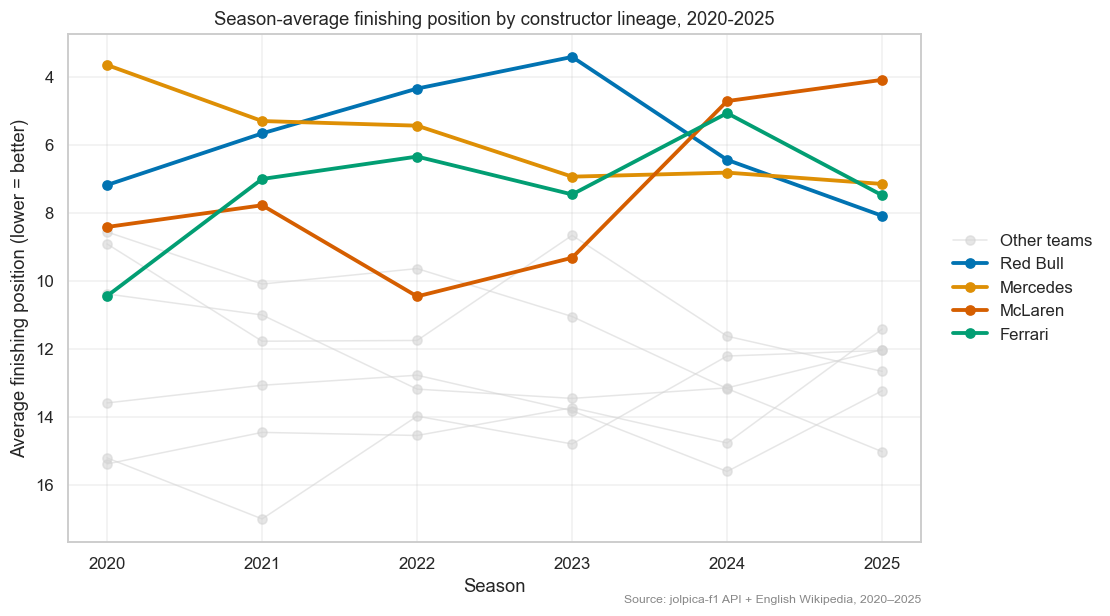

In [17]:
# Chart 1: Season-average position by constructor lineage, 2020-2025

# Build the small dataframe we need: one row per (constructor_lineage, season)
season_avg = (
    df.groupby(["constructor_lineage", "season"], as_index=False)["effective_position"]
    .mean()
    .rename(columns={"effective_position": "season_avg_position"})
)

# Order constructors by overall 2020-2025 mean so the legend reads top-down by strength
order = (
    season_avg.groupby("constructor_lineage")["season_avg_position"]
    .mean().sort_values().index.tolist()
)

# Per-team palette reused across all charts in this notebook for color consistency
palette = dict(zip(order, sns.color_palette("colorblind", n_colors=len(order))))

# Limit the palette for clarity: highlight the 4 teams that carry the era's narrative, grey the rest.
# In this chart only, highlight 4 teams that tell the era's narrative; grey the rest.
HIGHLIGHT = ["Red Bull", "Mercedes", "McLaren", "Ferrari"]

fig, ax = plt.subplots(figsize=(10, 6))

# Grey lines first (so they sit behind), single legend entry for "Other teams"
others = [l for l in order if l not in HIGHLIGHT]
for i, lineage in enumerate(others):
    rows = season_avg[season_avg["constructor_lineage"] == lineage]
    label = "Other teams" if i == 0 else None
    ax.plot(rows["season"], rows["season_avg_position"],
            marker="o", linewidth=1, color="lightgray", alpha=0.55, label=label)

# Highlighted lines on top
for lineage in HIGHLIGHT:
    rows = season_avg[season_avg["constructor_lineage"] == lineage]
    ax.plot(rows["season"], rows["season_avg_position"],
            marker="o", linewidth=2.5, label=lineage, color=palette[lineage])

ax.invert_yaxis()
ax.set_xlabel("Season")
ax.set_ylabel("Average finishing position (lower = better)")
ax.set_title("Season-average finishing position by constructor lineage, 2020-2025")
ax.set_xticks(sorted(df["season"].unique()))
ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)
ax.grid(True, alpha=0.3)

# Source attribution (Session 5 — Anatomy of a Good Chart: Data Source Note)
ax.text(1.0, -0.12, "Source: jolpica-f1 API + English Wikipedia, 2020–2025",
        transform=ax.transAxes, ha="right", fontsize=8, alpha=0.55)

out = FIGURES_DIR / "01_season_avg_over_time.png"
fig.savefig(out)
print(f"Saved {out}")

plt.show()

Saved ../reports/figures/02_delta_distribution.png

Distribution stats:
  Mean   :   0.000  (should be ~0 by construction)
  Median :  -0.604
  Std    :   4.171
  Min    : -12.455
  Max    :  15.917


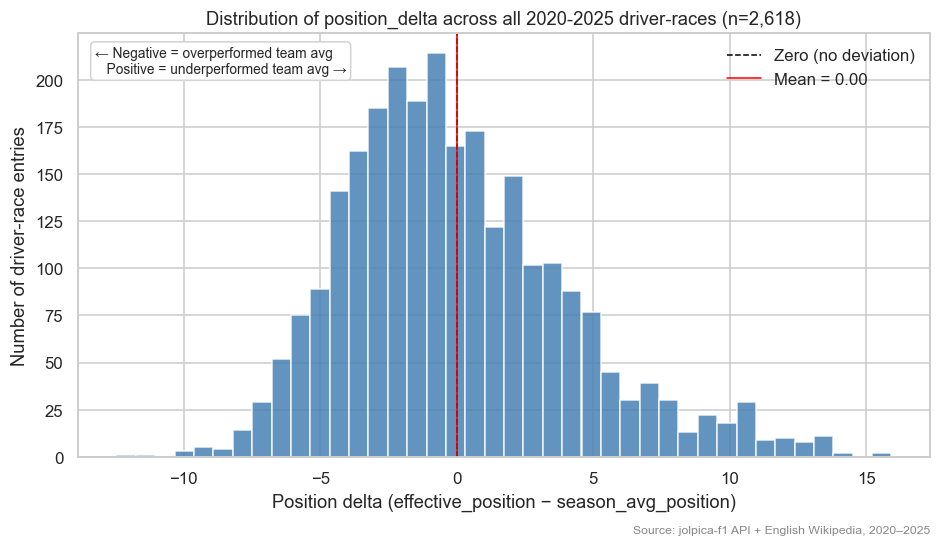

In [14]:
# Chart 2: Distribution of position_delta across all driver-races

fig, ax = plt.subplots(figsize=(10, 5))

deltas = df["position_delta"].dropna()
ax.hist(deltas, bins=40, color="steelblue", edgecolor="white", alpha=0.85)
ax.axvline(0, color="black", linestyle="--", linewidth=1, label="Zero (no deviation)")
ax.axvline(deltas.mean(), color="red", linestyle="-", linewidth=1, label=f"Mean = {deltas.mean():.2f}")

ax.set_xlabel("Position delta (effective_position − season_avg_position)")
ax.set_ylabel("Number of driver-race entries")
ax.set_title(f"Distribution of position_delta across all 2020-2025 driver-races (n={len(deltas):,})")
ax.legend(frameon=False)

# Annotate the interpretation
ax.text(0.02, 0.97,
        "← Negative = overperformed team avg\n   Positive = underperformed team avg →",
        transform=ax.transAxes, va="top", fontsize=9,
        bbox=dict(facecolor="white", edgecolor="lightgray", boxstyle="round,pad=0.3"))
# Source attribution (Session 5 — Anatomy of a Good Chart: Data Source Note)
ax.text(1.0, -0.18, "Source: jolpica-f1 API + English Wikipedia, 2020–2025",
        transform=ax.transAxes, ha="right", fontsize=8, alpha=0.55)

out = FIGURES_DIR / "02_delta_distribution.png"
fig.savefig(out)
print(f"Saved {out}")
print(f"\nDistribution stats:")
print(f"  Mean   : {deltas.mean():>7.3f}  (should be ~0 by construction)")
print(f"  Median : {deltas.median():>7.3f}")
print(f"  Std    : {deltas.std():>7.3f}")
print(f"  Min    : {deltas.min():>7.3f}")
print(f"  Max    : {deltas.max():>7.3f}")

plt.show()

Saved ../reports/figures/03_dnf_rate.png

DNF rate breakdown:
constructor_lineage  total_entries  dnf_entries  dnf_rate_pct
            McLaren            262           20      7.633588
           Mercedes            262           24      9.160305
           Red Bull            262           29     11.068702
            Ferrari            262           35     13.358779
             Sauber            262           37     14.122137
             Alpine            262           40     15.267176
      AlphaTauri/RB            262           41     15.648855
       Aston Martin            261           41     15.708812
               Haas            262           43     16.412214
           Williams            261           60     22.988506


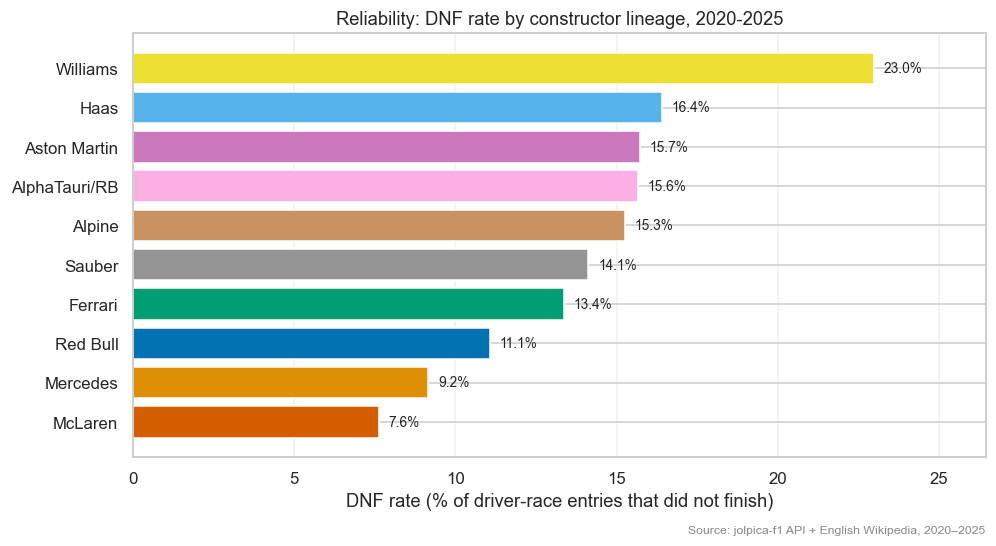

In [13]:
# Chart 3: DNF rate by constructor lineage

dnf_rate = (
    df.groupby("constructor_lineage")
    .agg(total_entries=("is_finisher", "count"),
         dnf_entries=("is_finisher", lambda s: (~s).sum()))
    .assign(dnf_rate_pct=lambda d: 100 * d["dnf_entries"] / d["total_entries"])
    .sort_values("dnf_rate_pct", ascending=True)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.barh(
    dnf_rate["constructor_lineage"],
    dnf_rate["dnf_rate_pct"],
    color=[palette[c] for c in dnf_rate["constructor_lineage"]],
    edgecolor="white",
)

# Label each bar with the percentage
for bar, pct in zip(bars, dnf_rate["dnf_rate_pct"]):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
            f"{pct:.1f}%", va="center", fontsize=9)

ax.set_xlabel("DNF rate (% of driver-race entries that did not finish)")
ax.set_title("Reliability: DNF rate by constructor lineage, 2020-2025")
ax.set_xlim(0, dnf_rate["dnf_rate_pct"].max() * 1.15)
ax.grid(True, alpha=0.3, axis="x")
# Source attribution (Session 5 — Anatomy of a Good Chart: Data Source Note)
ax.text(1.0, -0.18, "Source: jolpica-f1 API + English Wikipedia, 2020–2025",
        transform=ax.transAxes, ha="right", fontsize=8, alpha=0.55)
out = FIGURES_DIR / "03_dnf_rate.png"
fig.savefig(out)
print(f"Saved {out}")

print("\nDNF rate breakdown:")
print(dnf_rate[["constructor_lineage", "total_entries", "dnf_entries", "dnf_rate_pct"]].to_string(index=False))

plt.show()

Total unique circuits: 30
Circuits with 6 races : 5
Circuits with 1 race  : 2

Saved ../reports/figures/04_race_count_per_circuit.png


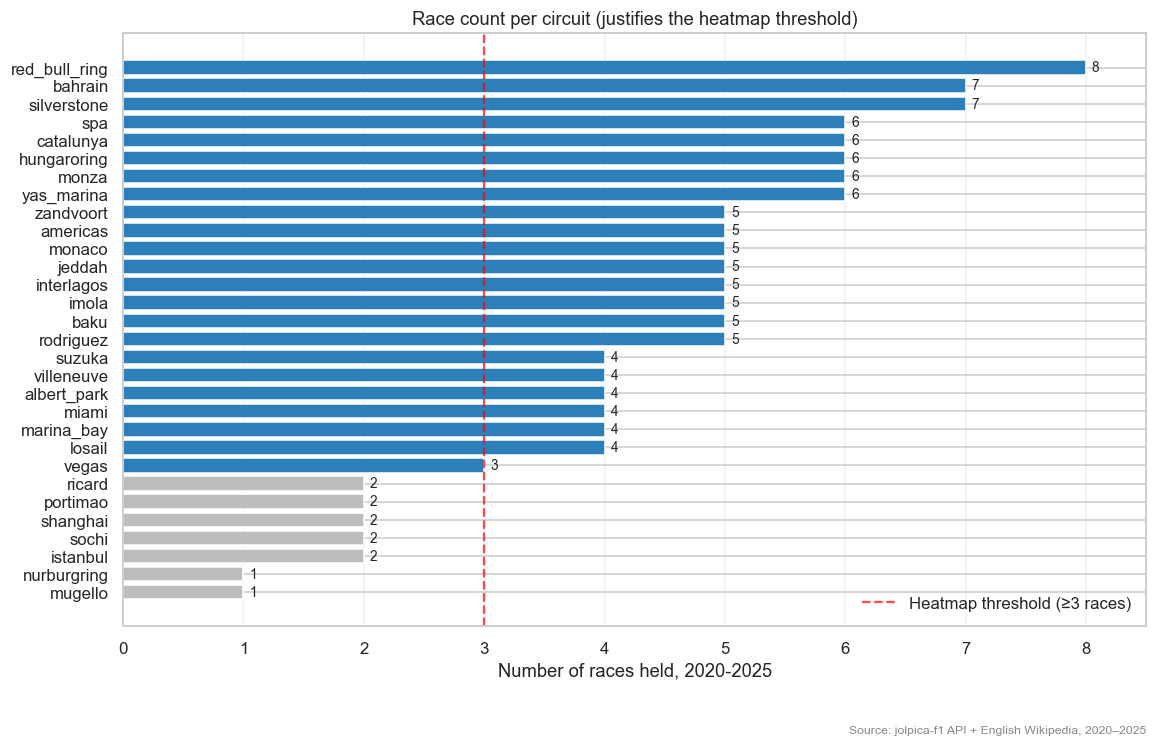

In [12]:
# Chart 4: Race count per circuit, 2020-2025
# Counts races as unique (season, round) pairs per circuit_id

race_counts = (
    df[["season", "round", "circuit_id"]]
    .drop_duplicates()
    .groupby("circuit_id")
    .size()
    .sort_values(ascending=False)
    .reset_index(name="race_count")
)

print(f"Total unique circuits: {len(race_counts)}")
print(f"Circuits with 6 races : {(race_counts['race_count'] == 6).sum()}")
print(f"Circuits with 1 race  : {(race_counts['race_count'] == 1).sum()}")

fig, ax = plt.subplots(figsize=(12, 7))

bars = ax.barh(
    race_counts["circuit_id"][::-1],         # reverse for top-down visual
    race_counts["race_count"][::-1],
    color=["#2c7fb8" if c >= 3 else "#bdbdbd" for c in race_counts["race_count"][::-1]],
    edgecolor="white",
)

# Reference line at threshold = 3
ax.axvline(3, color="red", linestyle="--", linewidth=1.5, alpha=0.7, label="Heatmap threshold (≥3 races)")

# Label bars
for bar, count in zip(bars, race_counts["race_count"][::-1]):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height() / 2,
            str(count), va="center", fontsize=9)

ax.set_xlabel("Number of races held, 2020-2025")
ax.set_title("Race count per circuit (justifies the heatmap threshold)")
ax.set_xlim(0, race_counts["race_count"].max() + 0.5)
ax.legend(loc="lower right", frameon=False)
ax.grid(True, alpha=0.3, axis="x")

# Source attribution (Session 5 — Anatomy of a Good Chart: Data Source Note)
ax.text(1.0, -0.18, "Source: jolpica-f1 API + English Wikipedia, 2020–2025",
        transform=ax.transAxes, ha="right", fontsize=8, alpha=0.55)


out = FIGURES_DIR / "04_race_count_per_circuit.png"
fig.savefig(out)
print(f"\nSaved {out}")

plt.show()

Heatmap matrix: 10 lineages × 30 circuits = 300 cells
  Filled cells (≥3 races): 230  (76.7%)
  Empty cells (below threshold)  : 70

Saved ../reports/figures/05_heatmap.png


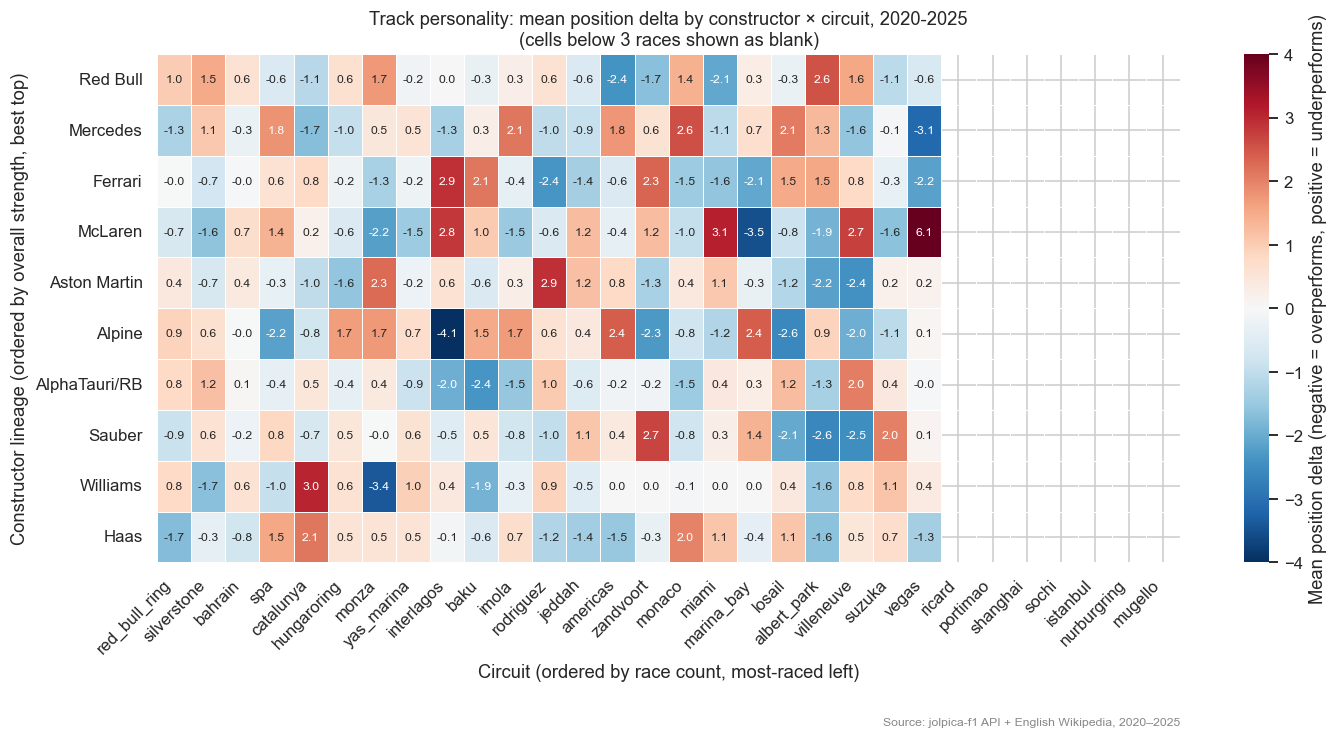

In [11]:
# Chart 5: THE HEATMAP — constructor lineage × circuit, mean position_delta
# Cells below 3 RACES per (lineage, circuit) pair are shown as NaN (blank).
#
# Counting rule: a "race" is a unique (season, round) pair, NOT a driver-entry.
# Drop_duplicates first → groupby → agg with "count" gives the correct race count.

THRESHOLD = 3

# Step 1a: count UNIQUE races per (lineage, circuit) pair
# Pattern: drop_duplicates → groupby → agg, taught in Session 4-5
race_counts_per_pair = (
    df[["constructor_lineage", "circuit_id", "season", "round"]]
    .drop_duplicates()
    .groupby(["constructor_lineage", "circuit_id"], as_index=False)
    .agg(n_races=("season", "count"))
)

# Step 1b: mean delta + driver-entry count per pair
pair_stats = (
    df.groupby(["constructor_lineage", "circuit_id"], as_index=False)
    .agg(
        mean_delta=("position_delta", "mean"),
        driver_entries=("position_delta", "count"),
    )
    .merge(race_counts_per_pair, on=["constructor_lineage", "circuit_id"])
)

# Step 2: mask pairs below threshold using n_races (the actual race count)
pair_stats["mean_delta_masked"] = pair_stats["mean_delta"].where(
    pair_stats["n_races"] >= THRESHOLD
)

# Step 3: pivot to a wide matrix (rows = lineage, cols = circuit)
heatmap_df = pair_stats.pivot(
    index="constructor_lineage",
    columns="circuit_id",
    values="mean_delta_masked",
)

# Step 4: order rows by overall constructor strength (best top to bottom)
heatmap_df = heatmap_df.reindex(order)

# Step 5: order columns by race count (most-raced first)
col_order = race_counts.sort_values("race_count", ascending=False)["circuit_id"].tolist()
heatmap_df = heatmap_df[col_order]

# Quick QA
total_cells = heatmap_df.size
filled_cells = heatmap_df.notna().sum().sum()
print(f"Heatmap matrix: {heatmap_df.shape[0]} lineages × {heatmap_df.shape[1]} circuits = {total_cells} cells")
print(f"  Filled cells (≥{THRESHOLD} races): {filled_cells}  ({100*filled_cells/total_cells:.1f}%)")
print(f"  Empty cells (below threshold)  : {total_cells - filled_cells}")

# Step 6: draw the heatmap
fig, ax = plt.subplots(figsize=(15, 6))

sns.heatmap(
    heatmap_df,
    cmap="RdBu_r",
    center=0,
    vmin=-4, vmax=4,
    annot=True, fmt=".1f",
    annot_kws={"size": 8},
    cbar_kws={"label": "Mean position delta (negative = overperforms, positive = underperforms)"},
    linewidths=0.5, linecolor="white",
    ax=ax,
)

ax.set_xlabel("Circuit (ordered by race count, most-raced left)")
ax.set_ylabel("Constructor lineage (ordered by overall strength, best top)")
ax.set_title(f"Track personality: mean position delta by constructor × circuit, 2020-2025\n(cells below {THRESHOLD} races shown as blank)")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

# Source attribution (Session 5 — Anatomy of a Good Chart: Data Source Note)
ax.text(1.0, -0.32, "Source: jolpica-f1 API + English Wikipedia, 2020–2025",
        transform=ax.transAxes, ha="right", fontsize=8, alpha=0.55)

out = FIGURES_DIR / "05_heatmap.png"
fig.savefig(out)
print(f"\nSaved {out}")

plt.show()

In [7]:
# Verify: what does the threshold ACTUALLY count?
# Our brief says "≥3 races per (constructor_lineage, circuit) pair"
# Our code uses position_delta.count() which counts driver-entries, not races

# Show the discrepancy on a small circuit
inspect = pair_stats[pair_stats["circuit_id"].isin(["mugello", "nurburgring", "istanbul"])].copy()

# Add: how many UNIQUE races did this circuit host, and how many for this lineage?
inspect["races_at_circuit"] = inspect["circuit_id"].map(
    df.groupby("circuit_id").apply(lambda g: g[["season", "round"]].drop_duplicates().shape[0])
)
inspect["driver_entries"]  = inspect["n_races"]   # this is what the code counted

# Mugello had 1 race. Each team has 2 drivers. So driver_entries should be 2 per team.
# But our threshold is "≥3" — so 2 should be BELOW threshold.

print("What `n_races` is actually counting (current code):")
print(inspect.sort_values(["circuit_id", "constructor_lineage"]).to_string(index=False))

print("\n" + "=" * 60)
print("Critical question: does Mugello show ANY filled cells in the heatmap?")
mugello_in_heatmap = heatmap_df["mugello"].notna().sum()
print(f"  Mugello filled cells in heatmap_df: {mugello_in_heatmap} (expected 0 if threshold is correct)")

What `n_races` is actually counting (current code):
constructor_lineage  circuit_id  mean_delta  driver_entries  n_races  mean_delta_masked  races_at_circuit
      AlphaTauri/RB    istanbul    0.558824               2        2                NaN                 2
             Alpine    istanbul    2.425134               2        2                NaN                 2
       Aston Martin    istanbul   -0.842246               2        2                NaN                 2
            Ferrari    istanbul   -3.970588               2        2                NaN                 2
               Haas    istanbul    2.147059               2        2                NaN                 2
            McLaren    istanbul    0.157754               2        2                NaN                 2
           Mercedes    istanbul    0.778743               2        2                NaN                 2
           Red Bull    istanbul   -1.917781               2        2                NaN             

Saved ../reports/figures/06_top_overperformance.png

Top 10 overperformance pairs:
constructor_lineage  circuit_id  mean_delta  n_races
             Alpine  interlagos   -4.092045        5
            McLaren  marina_bay   -3.516098        4
           Williams       monza   -3.382042        6
           Mercedes       vegas   -3.130051        3
             Sauber albert_park   -2.606061        4
             Alpine      losail   -2.580966        4
             Sauber  villeneuve   -2.481061        4
       Aston Martin  villeneuve   -2.423416        4
           Red Bull    americas   -2.385985        5
            Ferrari   rodriguez   -2.367424        5


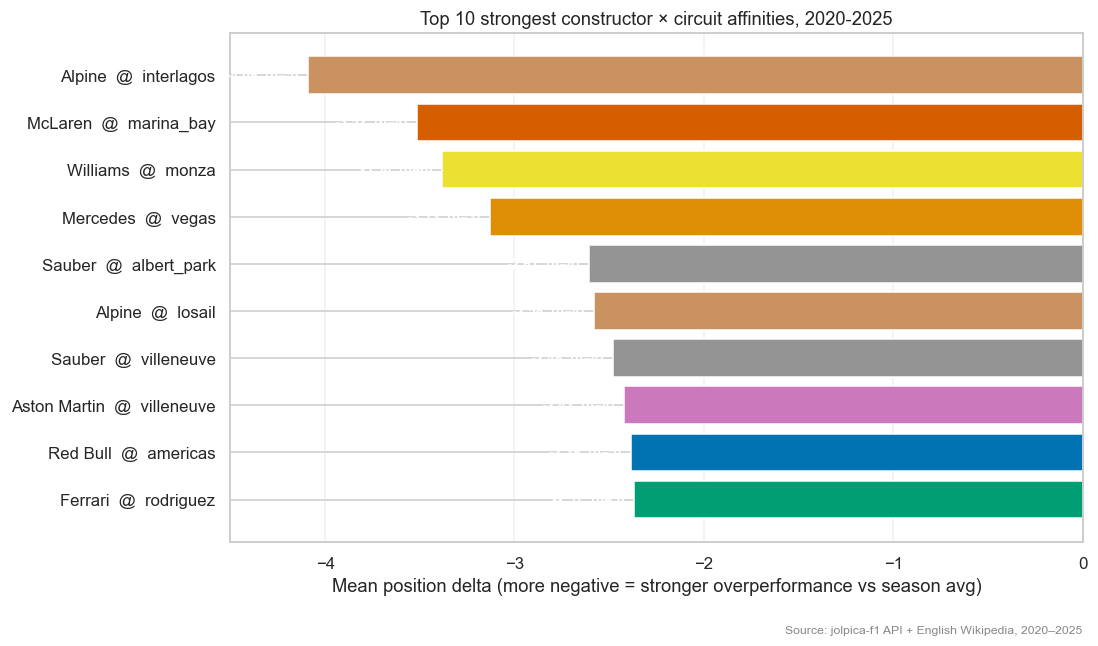

In [10]:
# Chart 6: Top 10 strongest overperformance pairs (most negative mean_delta)
# Filter to pairs that pass the ≥3 race threshold first

valid_pairs = pair_stats[pair_stats["n_races"] >= THRESHOLD].copy()
top10 = valid_pairs.nsmallest(10, "mean_delta").reset_index(drop=True)

# Build a readable label combining circuit and constructor
top10["label"] = top10["constructor_lineage"] + "  @  " + top10["circuit_id"]

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    top10["label"][::-1],
    top10["mean_delta"][::-1],
    color=[palette[c] for c in top10["constructor_lineage"][::-1]],
    edgecolor="white",
)

# Label each bar with the value
for bar, val, n in zip(bars, top10["mean_delta"][::-1], top10["n_races"][::-1]):
    ax.text(val - 0.05, bar.get_y() + bar.get_height() / 2,
            f"{val:.2f}  (n={n})", va="center", ha="right", fontsize=9, color="white", fontweight="bold")

ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Mean position delta (more negative = stronger overperformance vs season avg)")
ax.set_title("Top 10 strongest constructor × circuit affinities, 2020-2025")
ax.invert_xaxis()  # most negative on the right is more intuitive than left
ax.set_xlim(top10["mean_delta"].min() * 1.1, 0)
ax.grid(True, alpha=0.3, axis="x")
# Source attribution (Session 5 — Anatomy of a Good Chart: Data Source Note)
ax.text(1.0, -0.18, "Source: jolpica-f1 API + English Wikipedia, 2020–2025",
        transform=ax.transAxes, ha="right", fontsize=8, alpha=0.55)
out = FIGURES_DIR / "06_top_overperformance.png"
fig.savefig(out)
print(f"Saved {out}")

print("\nTop 10 overperformance pairs:")
print(top10[["constructor_lineage", "circuit_id", "mean_delta", "n_races"]].to_string(index=False))

plt.show()

## Three findings

### Finding 1 — Circuits have track-specific personalities that go beyond raw team strength

The heatmap reveals systematic constructor-circuit affinities that persist across multiple seasons. The strongest signal is **Alpine at Interlagos (Brazilian GP), mean position delta = −4.09 over 5 races**. Alpine finishes ~4 positions better at Interlagos than its own 2020-2025 season average — a deviation far larger than expected from noise. Other consistent affinities include **McLaren at Marina Bay (−3.5), Williams at Monza (−3.4), and Mercedes at Las Vegas (−3.1)**. These pairings suggest that the chassis/aero packages of certain constructors interact with specific circuit characteristics (low downforce setups for Monza, high-speed cold conditions at Vegas, kerb-heavy layouts at Interlagos) in ways that go beyond raw competitiveness. The methodological choice to use **`position_delta` rather than absolute position** is what surfaces these effects: subtracting the constructor's season average controls for "how good the team is overall" and isolates "how well the team fits this track."

### Finding 2 — Strong teams rarely appear in extreme affinities; weak teams do

A counterintuitive pattern: Red Bull, the dominant constructor of the 2020-2025 era, only appears once in the top-10 overperformance list (at Americas, −2.4). Mercedes appears once (Vegas), Ferrari once (Rodríguez). Conversely, **Alpine, McLaren, Williams, Sauber, and Aston Martin populate seven of the top 10 spots**. This is not noise — it's a property of the metric. A team that wins every race has a season average near P1 and *cannot* overperform that average; conversely, a midfield team that occasionally finishes P5 at one specific circuit produces a large negative delta against its midfield baseline. **This means the heatmap is best read as a "track personality" map for midfield teams**, where engineering compromises (downforce vs drag, mechanical grip vs aero, reliability vs pace) interact most visibly with circuit demands. It is less useful for the dominant teams, whose results are constrained by their own ceiling.

### Finding 3 — Data quality and methodology shape what we can and cannot claim

The headline patterns are descriptive, not causal, and rest on several methodological choices documented in `03_cleaning.ipynb`. (1) **Sample sizes are small** — even our most-raced circuits hosted at most 6-8 races, and 6 of 30 circuits had to be excluded from the heatmap because they hosted fewer than 3 races. (2) The **DNF rule** (`effective_position = finishers_count + 1` for non-finishers) treats a lap-1 retirement identically to a 95% race retirement, which is a deliberate simplification that punishes DNFs evenly but loses information about *how* a race went wrong. (3) The **constructor lineage decision** (continuous identity across rebrands) is defensible but not the only choice — splitting Racing Point from Aston Martin, or Renault from Alpine, would change the season averages and therefore every delta. (4) (4) **Track features (length, turns) were set from values verified against official F1 race-result pages** rather than the raw Wikipedia scrape; 16 of 30 circuits differed materially from the scrape because Wikipedia lists multiple historical layouts, so a single verified layout was used for every circuit.

In [9]:
# Persist key result tables for the slide deck / final report

ts = datetime.now().strftime("%Y%m%d_%H%M%S")
results_dir = Path("../reports")
results_dir.mkdir(parents=True, exist_ok=True)

# Heatmap matrix as CSV (rows = lineage, cols = circuit, values = mean delta)
heatmap_path = results_dir / f"heatmap_matrix_{ts}.csv"
heatmap_df.to_csv(heatmap_path)

# Top 10 + pair_stats with race counts
top10_path = results_dir / f"top10_overperformance_{ts}.csv"
top10[["constructor_lineage", "circuit_id", "mean_delta", "n_races"]].to_csv(top10_path, index=False)

all_pairs_path = results_dir / f"all_pairs_{ts}.csv"
pair_stats.to_csv(all_pairs_path, index=False)

print("Saved result tables:")
print(f"  {heatmap_path.name}      ({heatmap_path.stat().st_size:,} bytes)")
print(f"  {top10_path.name}    ({top10_path.stat().st_size:,} bytes)")
print(f"  {all_pairs_path.name}    ({all_pairs_path.stat().st_size:,} bytes)")

# Also list everything we've put in reports/figures/
print("\nAll figures in reports/figures/:")
for f in sorted(FIGURES_DIR.glob("*.png")):
    print(f"  {f.name}  ({f.stat().st_size:,} bytes)")

Saved result tables:
  heatmap_matrix_20260528_155439.csv      (4,932 bytes)
  top10_overperformance_20260528_155439.csv    (441 bytes)
  all_pairs_20260528_155439.csv    (17,082 bytes)

All figures in reports/figures/:
  01_season_avg_over_time.png  (212,809 bytes)
  02_delta_distribution.png  (97,235 bytes)
  03_dnf_rate.png  (89,875 bytes)
  04_race_count_per_circuit.png  (158,530 bytes)
  05_heatmap.png  (399,631 bytes)
  06_top_overperformance.png  (118,374 bytes)
